<h1>SImulação do modelo de Kuramoto - Redes Complexas<h1>
<h3>Katlyn Ribeiro <h3>

In [ ]:
#bibliotecas utilizadas
import numpy as np
#biblioteca usada para criar e manipolar grafos
import networkx as nx
#biblioteca para plotar caso necessario
import matplotlib.pyplot as plt


from tqdm import tqdm

Simulando Watts–Strogatz: 100%|██████████| 30/30 [01:03<00:00,  2.11s/it]


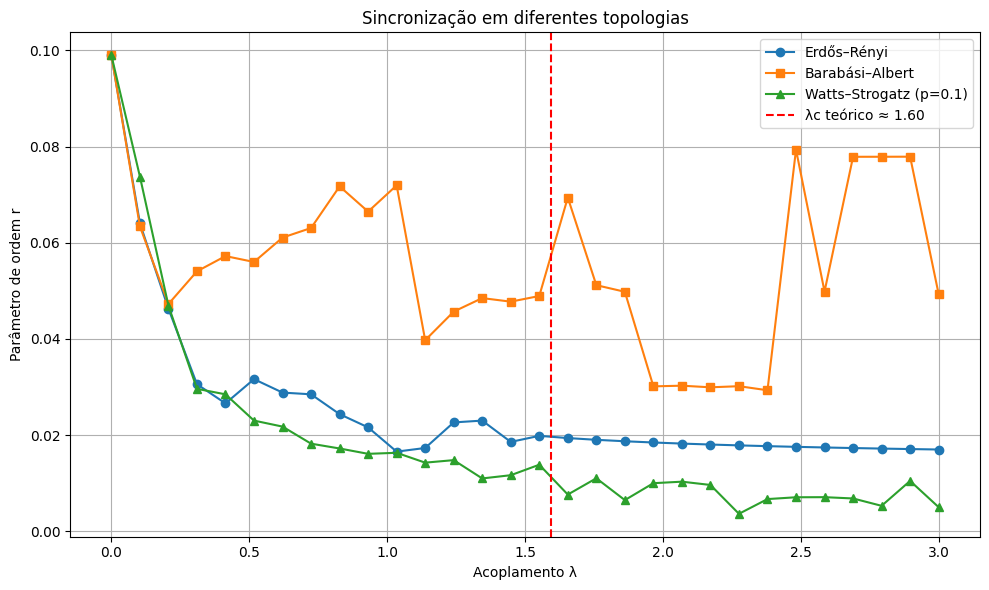

In [20]:
#parametros globais, utilizados em todo o codigo
N = 100  #número de nos
K_values = np.linspace(0, 3, 30)  #acoplamento λ
T = 100
dt = 0.1
t = np.arange(0, T, dt)

omega = np.random.normal(0, 1, N)

#inicia as fases
theta0 = np.random.uniform(0, 2*np.pi, N)

#aqui temos a funcaoo de simula o modelo de kuramoto
def kuramoto_deriv(theta, t, omega, K, A):
    N = len(theta)
    dtheta_dt = omega + K * np.sum(A * np.sin(np.subtract.outer(theta, theta)), axis=1)
    return dtheta_dt

#Aqui calculamos o parametro de ordem r
def order_parameter(theta):
    return np.abs(np.sum(np.exp(1j * theta)) / len(theta))

#roda as simulacoes
def simulate_kuramoto(G, name):
    A = nx.to_numpy_array(G)
    r_values = []

    for K in tqdm(K_values, desc=f"Simulando {name}"):
        sol = odeint(kuramoto_deriv, theta0, t, args=(omega, K, A))
        r_t = np.array([order_parameter(theta) for theta in sol])
        r_values.append(np.mean(r_t[int(len(r_t) * 0.5):]))  # média após transiente
    return r_values

#aqui sao geradas as redes
G_er = nx.erdos_renyi_graph(N, p=0.1)
G_ba = nx.barabasi_albert_graph(N, m=5)
G_ws = nx.watts_strogatz_graph(N, k=10, p=0.1)

#simular as redes com o modelo de kuramoto
r_er = simulate_kuramoto(G_er, "Erdős–Rényi")
r_ba = simulate_kuramoto(G_ba, "Barabási–Albert")
r_ws = simulate_kuramoto(G_ws, "Watts–Strogatz")





#area separada para plotar o grafico das curvas em funcao do acoplamento lambda
plt.figure(figsize=(10, 6))
plt.plot(K_values, r_er, label='Erdős–Rényi', marker='o')
plt.plot(K_values, r_ba, label='Barabási–Albert', marker='s')
plt.plot(K_values, r_ws, label='Watts–Strogatz (p=0.1)', marker='^')

#valor para o lambda (crítico teórico)
lambda_c = 2 / (np.pi * (1/np.sqrt(2*np.pi)))
plt.axvline(lambda_c, color='r', linestyle='--', label=f'λc teórico ≈ {lambda_c:.2f}')

plt.xlabel("Acoplamento λ")
plt.ylabel("Parâmetro de ordem r")
plt.title("Sincronização em diferentes topologias")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Simulando WS p=0.5: 100%|██████████| 30/30 [00:53<00:00,  1.78s/it]


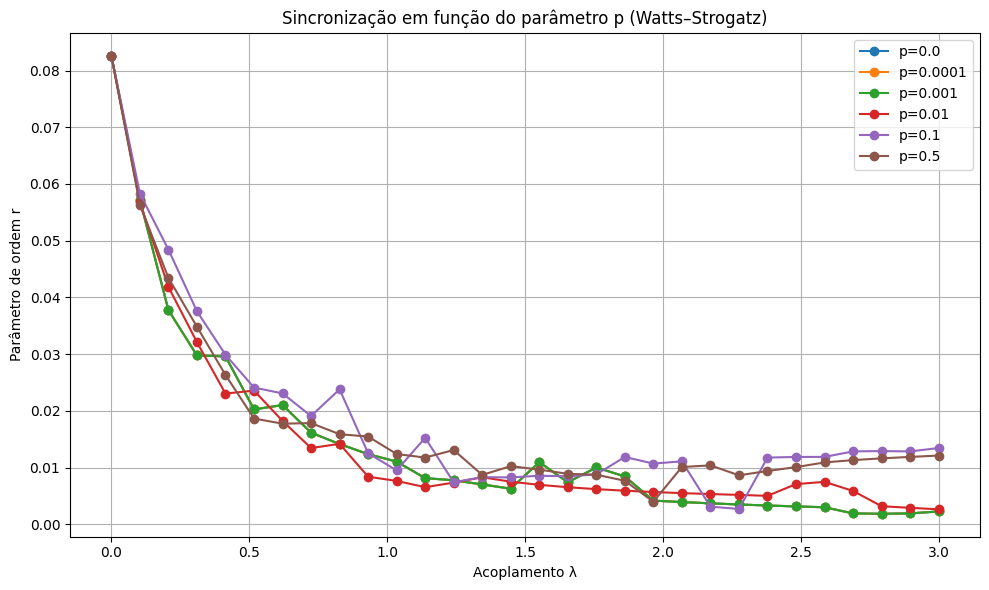

In [18]:
#para a parte 2, aqui temos os diferentes valores de p, solicitados
p_list = [0.0, 0.0001, 0.001, 0.01, 0.1, 0.5]

results_ws_p = {}

#modifica exclusivamente para o modelo watts-strogatz
for p in p_list:
    G = nx.watts_strogatz_graph(N, k=10, p=p)
    r_vals = simulate_kuramoto(G, f"WS p={p}")
    results_ws_p[p] = r_vals




#plotando agora com a mudança dos valores p
plt.figure(figsize=(10, 6))
for p in p_list:
    plt.plot(K_values, results_ws_p[p], label=f'p={p}', marker='o')


plt.xlabel("Acoplamento λ")
plt.ylabel("Parâmetro de ordem r")
plt.title("Sincronização em função do parâmetro p (Watts–Strogatz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
